In [46]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import os
from scipy.spatial import cKDTree



Track segment: 2.0% to 23.0% of full track
Point indices: 20 to 236 (out of 1028 total points)

Centerline segment length: 1074.49 meters
Raceline segment length: 1074.49 meters
Length difference (raceline vs centerline): 0.00 meters
Raceline is longer by 0.00m


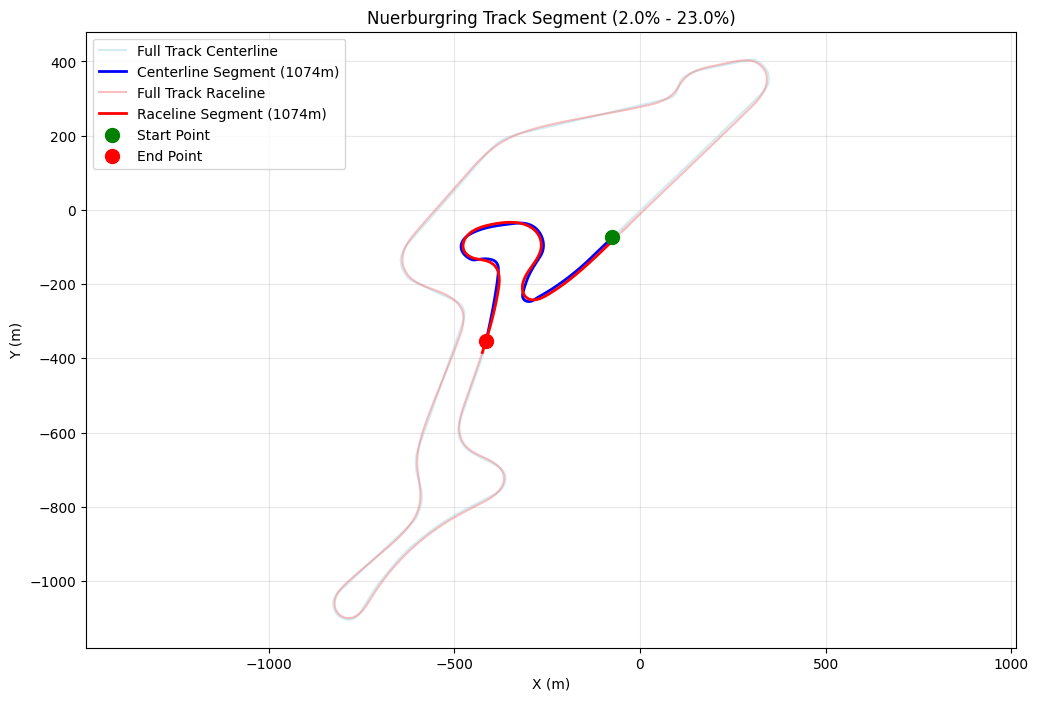

In [47]:
def load_track_data(track_name, base_path="../racetrack-database"):
    """
    Load track data
    
    Args:
        track_name: Track name (e.g., 'Silverstone')
        base_path: Database path
    
    Returns:
        track_data: Track centerline and width data
        raceline_data: Racing line data (if exists)
    """
    track_file = os.path.join(base_path, "tracks", f"{track_name}.csv")
    raceline_file = os.path.join(base_path, "racelines", f"{track_name}.csv")
    
    # Load track data
    if not os.path.exists(track_file):
        raise FileNotFoundError(f"Track file not found: {track_file}")
    
    track_data = pd.read_csv(track_file, comment='#')
    track_data.columns = ['x_m', 'y_m', 'w_tr_right_m', 'w_tr_left_m']
    
    # Load racing line data (if exists)
    raceline_data = None
    if os.path.exists(raceline_file):
        raceline_data = pd.read_csv(raceline_file, comment='#')
        raceline_data.columns = ['x_m', 'y_m']
        # Ensure raceline has the same number of points as centerline for simplicity
        if len(raceline_data) != len(track_data):
            # Interpolate raceline data
            path_x = raceline_data['x_m'].values
            path_y = raceline_data['y_m'].values
            distance = np.cumsum(np.sqrt(np.diff(path_x, prepend=path_x[0])**2 + np.diff(path_y, prepend=path_y[0])**2))
            f_x = interp1d(distance, path_x, kind='cubic', fill_value="extrapolate")
            f_y = interp1d(distance, path_y, kind='cubic', fill_value="extrapolate")

            center_x = track_data['x_m'].values
            center_y = track_data['y_m'].values
            center_dist = np.cumsum(np.sqrt(np.diff(center_x, prepend=center_x[0])**2 + np.diff(center_y, prepend=center_y[0])**2))
            
            new_raceline_x = f_x(center_dist)
            new_raceline_y = f_y(center_dist)
            raceline_data = pd.DataFrame({'x_m': new_raceline_x, 'y_m': new_raceline_y})

    return track_data, raceline_data

def calculate_track_boundaries(track_data):
    """
    Calculate track boundary points
    
    Args:
        track_data: Data containing centerline and width information
    
    Returns:
        left_boundary: Left boundary points
        right_boundary: Right boundary points
        normals: Normal vectors for each centerline point
    """
    x = track_data['x_m'].values
    y = track_data['y_m'].values
    w_right = track_data['w_tr_right_m'].values
    w_left = track_data['w_tr_left_m'].values
    
    # Calculate tangent direction (along track direction)
    dx = np.gradient(x)
    dy = np.gradient(y)
    
    # Normalize tangent vectors
    tangent_length = np.sqrt(dx**2 + dy**2)
    tangent_length = np.where(tangent_length == 0, 1e-10, tangent_length)
    dx_norm = dx / tangent_length
    dy_norm = dy / tangent_length
    
    # Calculate normal vectors (perpendicular to track)
    nx = -dy_norm  # Normal vector x component
    ny = dx_norm   # Normal vector y component
    
    # Calculate boundary points
    left_boundary_x = x + w_left * nx
    left_boundary_y = y + w_left * ny
    right_boundary_x = x - w_right * nx
    right_boundary_y = y - w_right * ny
    
    left_boundary = np.column_stack([left_boundary_x, left_boundary_y])
    right_boundary = np.column_stack([right_boundary_x, right_boundary_y])
    normals = np.column_stack([nx, ny])
    
    return left_boundary, right_boundary, normals

# Load data for Nuerburgring
track_name = 'Nuerburgring'
track_data, raceline_data = load_track_data(track_name, base_path="../racetrack-database")
left_boundary, right_boundary, normals = calculate_track_boundaries(track_data)

# ----------------------------
# Calculate Track Segment Lengths (2% - 23%)
# ----------------------------
def calculate_path_length(x_coords, y_coords):
    """Calculate the total length of a path given x,y coordinates"""
    distances = np.sqrt(np.diff(x_coords)**2 + np.diff(y_coords)**2)
    return np.sum(distances)

# Define the segment we'll be using (2% to 23%)
start_percent = 0.02
end_percent = 0.23
total_points = len(track_data)
start_idx = int(start_percent * total_points)
end_idx = int(end_percent * total_points)

print(f"Track segment: {start_percent*100:.1f}% to {end_percent*100:.1f}% of full track")
print(f"Point indices: {start_idx} to {end_idx} (out of {total_points} total points)")

# Extract the segment coordinates
centerline_segment_x = track_data['x_m'].iloc[start_idx:end_idx].values
centerline_segment_y = track_data['y_m'].iloc[start_idx:end_idx].values

# Calculate centerline segment length
centerline_length = calculate_path_length(centerline_segment_x, centerline_segment_y)
print(f"\nCenterline segment length: {centerline_length:.2f} meters")

# Calculate raceline segment length if available
if raceline_data is not None:
    raceline_segment_x = raceline_data['x_m'].iloc[start_idx:end_idx].values
    raceline_segment_y = raceline_data['y_m'].iloc[start_idx:end_idx].values
    raceline_length = calculate_path_length(raceline_segment_x, raceline_segment_y)
    print(f"Raceline segment length: {raceline_length:.2f} meters")
    print(f"Length difference (raceline vs centerline): {raceline_length - centerline_length:.2f} meters")
    print(f"Raceline is {'shorter' if raceline_length < centerline_length else 'longer'} by {abs(raceline_length - centerline_length):.2f}m")
else:
    print("Raceline data not available")

# Visualize the segment we'll be using
plt.figure(figsize=(12, 8))
plt.plot(track_data['x_m'], track_data['y_m'], 'lightblue', alpha=0.5, label='Full Track Centerline')
plt.plot(centerline_segment_x, centerline_segment_y, 'b-', linewidth=2, label=f'Centerline Segment ({centerline_length:.0f}m)')

if raceline_data is not None:
    plt.plot(raceline_data['x_m'], raceline_data['y_m'], 'lightcoral', alpha=0.5, label='Full Track Raceline')
    plt.plot(raceline_segment_x, raceline_segment_y, 'r-', linewidth=2, label=f'Raceline Segment ({raceline_length:.0f}m)')

# Highlight start and end points
plt.scatter(centerline_segment_x[0], centerline_segment_y[0], c='green', s=100, label='Start Point', zorder=5)
plt.scatter(centerline_segment_x[-1], centerline_segment_y[-1], c='red', s=100, label='End Point', zorder=5)

plt.axis('equal')
plt.legend()
plt.title(f'{track_name} Track Segment ({start_percent*100:.1f}% - {end_percent*100:.1f}%)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid(True, alpha=0.3)
plt.show()


In [48]:
# ----------------------------
# Parameters and Vehicle Dynamics
# ----------------------------
state_steps = 100
control_steps = state_steps - 1

# Control limits（保持你的参数名与数值）
a_max = 30.0    # 最大纵向加速度 [m/s^2]
a_min = -30.0   # 最大纵向减速度(制动) [m/s^2]
delta_max = 0.4 # 最大转角 [rad] (~23°)

# Fixed dt value (no longer optimized)
dt_fixed = 0.2  # 固定步长 [s]

# —— 新增的合理车辆参数与限幅（不改你现有参数名，仅新增）——
L_wb = 3.6            # 轴距 [m]（F1 量级）
deltadot_max = 6.0    # 转角角速度上限 [rad/s]
v_top = 95.0          # 最高车速上限 [m/s]（~342 km/h，数值稳定用）

def a_long_limits(v):
    """速度相关的纵向加速/制动能力上限（经验简化版，F1 量级）
    返回: (a_eng_max, a_brk_max)，分别为加速上限与制动上限的正值
    """
    a_eng = max(0.0, 18.0 - 0.004 * (v**2))   # 动力随速衰减，低速~1.8 g
    a_brk = min(45.0, 20.0 + 0.01 * (v**2))   # 刹车随速略升，封顶~4.6 g
    return a_eng, a_brk

def simulate_vehicle(x0, u_seq, dt, state_steps=100):
    """
    基于“简化自行车模型”的离散推进（保持原状态维度与返回形状不变）:
      状态: [x, y, theta, v, r]，其中 r = (v/L_wb)*tan(delta) 为“实时计算”的偏航角速度
      控制: [a, delta]，对 delta 施加角速度限幅，对 a 施加速度相关的纵向限幅

    离散更新:
      r_k      = (v_k / L_wb) * tan(delta_k_eff)
      x_{k+1}  = x_k + dt * v_k * cos(theta_k)
      y_{k+1}  = y_k + dt * v_k * sin(theta_k)
      theta_{k+1} = theta_k + dt * r_k
      v_{k+1}  = clip(v_k + dt * a_k_eff, 0, v_top)
      r_{k+1}  = (v_{k+1} / L_wb) * tan(delta_k_eff)   # 仅作为记录输出

    返回:
      states: 形状 (state_steps, 5) 的数组
    """
    control_steps = state_steps - 1
    states = np.zeros((state_steps, 5), dtype=float)
    states[0] = x0

    # 复制以避免原始序列被外部修改
    u_seq = np.array(u_seq, dtype=float).copy()

    # 基础幅度限幅（保留你原有的 a/delta 外层限制）
    u_seq[:, 0] = np.clip(u_seq[:, 0], a_min, a_max)
    u_seq[:, 1] = np.clip(u_seq[:, 1], -delta_max, delta_max)

    # 转角速率限幅需要“上一时刻实际应用的转角”
    delta_prev = float(np.clip(u_seq[0, 1], -delta_max, delta_max))

    for k in range(control_steps):
        x, y, theta, v, _ = states[k]
        a_cmd, delta_cmd = u_seq[k]

        # 1) 转角角速度限幅（先按速率限幅，再确保幅度限幅）
        max_step = deltadot_max * dt
        delta_eff = np.clip(delta_cmd, delta_prev - max_step, delta_prev + max_step)
        delta_eff = float(np.clip(delta_eff, -delta_max, delta_max))

        # 2) 纵向加减速“速度相关”的二次限幅
        a_eng_max, a_brk_max = a_long_limits(v)
        a_upper = min(a_max, a_eng_max)     # 上界取更严格者
        a_lower = max(a_min, -a_brk_max)    # 下界取更严格者（注意制动为负）
        a_eff = float(np.clip(a_cmd, a_lower, a_upper))

        # 3) 基于简化自行车模型计算 r（非积分状态，而是由 delta 派生）
        r = (v / L_wb) * np.tan(delta_eff)

        # 4) 状态推进
        x_next = x + dt * v * np.cos(theta)
        y_next = y + dt * v * np.sin(theta)
        theta_next = theta + dt * r
        v_next = np.clip(v + dt * a_eff, 0.0, v_top)
        r_next = (v_next / L_wb) * np.tan(delta_eff)  # 仅作记录

        states[k + 1] = [x_next, y_next, theta_next, v_next, r_next]

        # 更新上一时刻实际应用的转角
        delta_prev = delta_eff

    return states


In [49]:
# ----------------------------
# Cost Function for Trajectory Optimization
# ----------------------------

def find_closest_point_index(point, path):
    """Find the index of the closest point on a path to a given point."""
    path_points = path[['x_m', 'y_m']].values
    distances = np.linalg.norm(path_points - point, axis=1)
    return np.argmin(distances)

def make_index_schedules(centerline_df, raceline_df, N_states):
    """为中心线(走廊约束)与参考线(跟随)分别生成均匀索引表"""
    M_c = len(centerline_df)
    idx_c = np.linspace(0, M_c - 1, N_states).round().astype(int)
    if raceline_df is None:
        idx_r = idx_c
    else:
        M_r = len(raceline_df)
        idx_r = np.linspace(0, M_r - 1, N_states).round().astype(int)
    return idx_c, idx_r

def lane_barrier_penalty_nn(positions, SEG, margin=0.6, weight=2e6, p=2):
    """
    最近邻中心线走廊惩罚（越界 -> 铰链^p，默认 p=2；可设 p=4 更硬）。
    允许区间：[-w_right+margin,  w_left-margin]
    """
    # 最近邻中心线索引
    _, idx = SEG['kdtree'].query(positions)  # shape: (N,)
    n = SEG['normals'][idx]
    c = SEG['center_xy'][idx]
    wL = SEG['w_left'][idx]
    wR = SEG['w_right'][idx]
    # 侧向偏移（沿法向）
    offset = np.sum((positions - c) * n, axis=1)
    # 越界量（>0 表示违反）
    v_left  = np.maximum(0.0, offset - (wL - margin))
    v_right = np.maximum(0.0, (-wR + margin) - offset)
    # 惩罚
    if p == 2:
        pen = np.sum(v_left*v_left + v_right*v_right)
    else:
        pen = np.sum(v_left**p + v_right**p)
    return weight * pen, idx

def progress_monotonic_penalty(idx, SEG, weight=2e4):
    """
    弧长单调性惩罚：鼓励 s_{k+1} >= s_k。
    用最近邻索引把每帧映射到弧长 s(idx)，对负的增量加铰链^2。
    """
    s = SEG['s'][idx]
    ds = np.diff(s)
    back = np.maximum(0.0, -ds)  # 只罚“倒退”
    return weight * np.sum(back*back)

def heading_align_penalty(theta, idx, SEG, weight=0.2):
    """
    车头朝向对齐中心线切向的小惩罚（避免贴墙横滑）。
    """
    psi = SEG['psi'][idx]
    # wrap 到 [-pi, pi]
    d = (theta - psi + np.pi) % (2*np.pi) - np.pi
    return weight * np.sum(d*d)

def raceline_progress_reward(positions, raceline_df, weight=50.0):
    """
    沿赛道线的前进奖励项：计算在赛道线上的前进距离
    """
    if raceline_df is None:
        return 0.0
    
    raceline_xy = raceline_df[['x_m', 'y_m']].values
    
    # 为每个位置找到最近的赛道线点
    distances = np.linalg.norm(raceline_xy[np.newaxis, :, :] - positions[:, np.newaxis, :], axis=2)
    closest_indices = np.argmin(distances, axis=1)
    
    # 计算沿赛道线的前进进度（索引增加 = 前进）
    progress = np.diff(closest_indices.astype(float))
    # 只奖励正向前进，忽略负向（可能由于噪声）
    forward_progress = np.sum(np.maximum(0, progress))
    
    return -weight * forward_progress  # 负号因为我们要最小化成本

def movement_penalty(positions, weight=500.0):
    """
    强化不移动惩罚：强烈惩罚总移动距离过小和停滞行为
    """
    if len(positions) < 2:
        return 0.0
    
    # 计算总移动距离
    total_distance = 0.0
    segment_distances = []
    for i in range(1, len(positions)):
        dist = np.linalg.norm(positions[i] - positions[i-1])
        total_distance += dist
        segment_distances.append(dist)
    
    # 期望的最小移动距离（更严格）
    expected_min_distance = 800.0  # 期望至少移动800米
    
    # 基础距离惩罚
    distance_penalty = 0.0
    if total_distance < expected_min_distance:
        distance_penalty = (expected_min_distance - total_distance) ** 2
    
    # 停滞惩罚：惩罚连续的小移动
    stagnation_penalty = 0.0
    if segment_distances:
        avg_segment_dist = np.mean(segment_distances)
        min_expected_segment = 5.0  # 每步至少移动5米
        if avg_segment_dist < min_expected_segment:
            stagnation_penalty = (min_expected_segment - avg_segment_dist) ** 2 * len(segment_distances)
    
    # 倒退惩罚：检查是否有明显的倒退行为
    backward_penalty = 0.0
    if len(positions) >= 3:
        for i in range(2, len(positions)):
            # 检查是否偏离总体前进方向
            overall_direction = positions[-1] - positions[0]
            if np.linalg.norm(overall_direction) > 0:
                overall_direction = overall_direction / np.linalg.norm(overall_direction)
                step_direction = positions[i] - positions[i-1]
                if np.linalg.norm(step_direction) > 0:
                    step_direction = step_direction / np.linalg.norm(step_direction)
                    # 如果步骤方向与总体方向夹角大于90度，认为是倒退
                    if np.dot(step_direction, overall_direction) < 0:
                        backward_penalty += 1000.0
    
    return weight * (distance_penalty + stagnation_penalty + backward_penalty)

def raceline_guidance_cost(positions, raceline_df, weight=10.0):
    """
    强化赛道线引导：鼓励跟随赛道线而不是中心线
    """
    if raceline_df is None:
        return 0.0
    
    raceline_xy = raceline_df[['x_m', 'y_m']].values
    
    # 计算到赛道线的距离
    distances = []
    for pos in positions:
        dist_to_raceline = np.min(np.linalg.norm(raceline_xy - pos, axis=1))
        distances.append(dist_to_raceline)
    
    return weight * np.sum(np.array(distances) ** 2)

def enhanced_forward_reward(positions, raceline_df, weight=500.0):
    """
    增强的前进奖励：鼓励沿赛道线方向前进
    """
    if len(positions) < 2:
        return 0.0
    
    start_pos = positions[0]
    end_pos = positions[-1]
    
    # 计算实际前进向量
    actual_displacement = end_pos - start_pos
    actual_distance = np.linalg.norm(actual_displacement)
    
    if actual_distance == 0:
        return 0.0
    
    # 计算赛道线的目标方向
    if raceline_df is not None:
        raceline_xy = raceline_df[['x_m', 'y_m']].values
        # 使用赛道线起点和终点确定总体方向
        target_direction = raceline_xy[-1] - raceline_xy[0]
        target_direction = target_direction / np.linalg.norm(target_direction)
    else:
        # 如果没有赛道线，假设沿X轴正方向
        target_direction = np.array([1.0, 0.0])
    
    # 计算与目标方向的对齐度
    actual_direction = actual_displacement / actual_distance
    alignment = np.dot(actual_direction, target_direction)  # cos(angle)
    
    # 只奖励正向前进
    if alignment > 0:
        # 奖励 = 距离 × 对齐度^2
        forward_reward = actual_distance * (alignment ** 2)
    else:
        forward_reward = 0.0
    
    return -weight * forward_reward

def steering_penalty(u_seq, weight=50.0):
    """
    转向惩罚：减少不必要的转向以避免转圈
    """
    steering_angles = u_seq[:, 1]
    # 惩罚大的转向角度和转向变化
    angle_penalty = np.sum(np.abs(steering_angles))
    change_penalty = np.sum(np.abs(np.diff(steering_angles)))
    return weight * (angle_penalty + change_penalty)

def progressive_speed_reward(states, target_speed=30.0, weight=100.0):
    """
    渐进式速度奖励：鼓励逐渐加速到目标速度
    """
    speeds = states[:, 3]
    
    # 奖励接近目标速度的行为
    speed_errors = np.abs(speeds - target_speed)
    speed_reward = np.sum(np.maximum(0, target_speed - speed_errors))
    
    # 额外奖励速度的增长（从慢到快）
    speed_increases = np.maximum(0, np.diff(speeds))
    growth_reward = np.sum(speed_increases)
    
    return -weight * (speed_reward + growth_reward)

def efficiency_reward(positions, weight=1000.0):
    """
    效率奖励：强烈奖励高效率的直线运动
    """
    if len(positions) < 2:
        return 0.0
    
    straight_line_distance = np.linalg.norm(positions[-1] - positions[0])
    total_distance = np.sum([np.linalg.norm(positions[i+1] - positions[i]) for i in range(len(positions)-1)])
    
    if total_distance > 0:
        efficiency = straight_line_distance / total_distance
        # 强烈奖励高效率的运动
        return -weight * straight_line_distance * efficiency
    else:
        return 0.0

def cost_function(vars_flat, x0, centerline, raceline, normals):
    dt = dt_fixed
    u_seq = vars_flat.reshape((control_steps, 2))
    states = simulate_vehicle(x0, u_seq, dt, state_steps)

    # 轨迹位置/速度/朝向
    pos   = states[:, :2]
    v     = states[:, 3]
    theta = states[:, 2]

    # 参考线
    ref_df = raceline if raceline is not None else centerline
    ref_xy = ref_df[['x_m','y_m']].values
    # 依据状态步长在参考线上均匀采样（仅用于“贴线”项）
    M_r = len(ref_df)
    idx_r = np.linspace(0, M_r - 1, state_steps).round().astype(int)

    # ---- 权重（基于成功测试的配置）----
    w_track    = 2.0    # 参考线跟随权重（降低以避免过度约束）
    w_barrier  = 1.0    # 走廊惩罚外层倍率
    w_energy   = 0.001  # 极低的能量惩罚，允许激进控制
    w_smooth   = 0.3    # 降低平滑性要求
    w_speed    = 0.1    # 降低原始速度惩罚权重
    w_terminal = 10.0   # 降低终端权重，让前进奖励主导
    w_prog     = 1.0    # 弧长单调项权重
    w_head     = 0.2    # 朝向对齐项
    w_movement = 0.3    # 不移动惩罚权重
    w_raceline_guide = 0.3     # 赛道线引导权重
    # 新的成功权重配置
    w_enhanced_forward = 1.0   # 增强前进奖励（主要驱动力）
    w_steering_penalty = 1.0   # 转向惩罚（避免转圈）  
    w_progressive_speed = 1.0  # 渐进速度奖励
    w_efficiency = 2.0         # 效率奖励（强烈鼓励直线运动）

    # 1) 参考线贴合
    ref_err = pos - ref_xy[idx_r]
    cost_track = np.sum(ref_err[:,0]**2 + ref_err[:,1]**2)

    # 2) 新的走廊惩罚（最近邻）
    cost_corridor, idx_nn = lane_barrier_penalty_nn(
        positions=pos, SEG=SEG, margin=0.6, weight=2e6, p=2
    )

    # 3) 控制能量 & 平滑
    cost_energy = np.sum(u_seq**2)
    cost_smooth = np.sum(np.diff(u_seq, axis=0)**2)

    # 4) 原始速度惩罚（降低权重）
    target_speed = 25.0  
    cost_speed = np.sum((np.maximum(0.0, target_speed - v))**2)

    # 5) 终端到达（对参考线末端）
    target = ref_xy[-1]
    cost_terminal = np.sum((states[-1, :2] - target)**2)

    # 6) 弧长单调性（防倒退/抄近道）
    cost_prog = progress_monotonic_penalty(idx_nn, SEG, weight=2e4)

    # 7) 朝向对齐（小权重，抑制“横着挤墙”）
    cost_head = heading_align_penalty(theta, idx_nn, SEG, weight=0.2)

    # 8) 不移动惩罚（降低权重）
    cost_movement = movement_penalty(pos, weight=100.0)

    # 9) 赛道线引导
    cost_raceline_guide = raceline_guidance_cost(pos, raceline, weight=10.0)

    # 10) 新的成功成本项
    # 增强前进奖励（主要驱动力）
    cost_enhanced_forward = enhanced_forward_reward(pos, raceline, weight=500.0)
    
    # 转向惩罚（避免转圈）
    cost_steering = steering_penalty(u_seq, weight=30.0)
    
    # 渐进速度奖励
    cost_progressive_speed = progressive_speed_reward(states, target_speed=25.0, weight=50.0)
    
    # 效率奖励（强烈鼓励直线运动）
    cost_efficiency = efficiency_reward(pos, weight=1000.0)

    total_cost = (w_track * cost_track +
                  w_barrier * cost_corridor +
                  w_energy * cost_energy +
                  w_smooth * cost_smooth +
                  w_speed * cost_speed +
                  w_terminal * cost_terminal +
                  w_prog * cost_prog +
                  w_head * cost_head +
                  w_movement * cost_movement +
                  w_raceline_guide * cost_raceline_guide +
                  w_enhanced_forward * cost_enhanced_forward +
                  w_steering_penalty * cost_steering +
                  w_progressive_speed * cost_progressive_speed +
                  w_efficiency * cost_efficiency)
    
    return total_cost




In [ ]:
# ----------------------------
# MPC Control Implementation
# ----------------------------

def mpc_control_step(current_state, centerline, raceline, normals, SEG, mpc_horizon=10):
    """
    执行单步MPC控制
    
    Args:
        current_state: 当前状态 [x, y, theta, v, r]
        centerline: 中心线数据
        raceline: 赛道线数据
        normals: 法向量
        SEG: 赛段几何信息
        mpc_horizon: MPC预测范围
        
    Returns:
        optimal_control: 最优控制 [a, delta]
        predicted_states: 预测状态序列
    """
    # MPC参数
    mpc_steps = min(mpc_horizon, control_steps)
    
    # 设置MPC边界条件
    mpc_bounds = []
    for _ in range(mpc_steps):
        mpc_bounds.append((a_min, a_max))
        mpc_bounds.append((-delta_max, delta_max))
    
    # 智能初始猜测基于当前状态和赛道线
    mpc_vars0 = np.zeros(mpc_steps * 2)
    mpc_u0 = mpc_vars0.reshape(mpc_steps, 2)
    
    # 基于当前速度设置加速度
    current_speed = current_state[3]
    target_speed = 25.0
    
    if current_speed < target_speed:
        # 需要加速
        mpc_u0[:, 0] = min(15.0, target_speed - current_speed)
    else:
        # 维持速度或轻微减速
        mpc_u0[:, 0] = 5.0
    
    # 基于赛道线计算转向
    if raceline is not None:
        current_pos = current_state[:2]
        raceline_xy = raceline[['x_m', 'y_m']].values
        
        # 找到当前位置最近的赛道线点
        distances = np.linalg.norm(raceline_xy - current_pos, axis=1)
        closest_idx = np.argmin(distances)
        
        # 预测前方赛道线点
        future_indices = np.clip(closest_idx + np.arange(1, mpc_steps+1), 
                                 0, len(raceline_xy)-1)
        
        # 计算转向角度
        for i in range(mpc_steps):
            if i < len(future_indices):
                target_point = raceline_xy[future_indices[i]]
                direction = target_point - current_pos
                target_heading = np.arctan2(direction[1], direction[0])
                current_heading = current_state[2]
                
                # 计算转向角度差异
                heading_diff = target_heading - current_heading
                heading_diff = (heading_diff + np.pi) % (2*np.pi) - np.pi
                
                # 设置适当的转向角度（限制在合理范围内）
                mpc_u0[i, 1] = np.clip(heading_diff * 0.3, -delta_max*0.5, delta_max*0.5)
    
    mpc_vars0 = mpc_u0.ravel()
    
    # 定义MPC成本函数
    def mpc_cost_function(vars_flat):
        u_seq = vars_flat.reshape((mpc_steps, 2))
        
        # 填充控制序列到完整长度
        u_seq_full = np.zeros((control_steps, 2))
        u_seq_full[:mpc_steps] = u_seq
        # 后续步骤保持最后一个控制输入
        if mpc_steps < control_steps:
            u_seq_full[mpc_steps:] = u_seq[-1]
        
        # 使用相同的成本函数，但起始状态为当前状态
        return cost_function(u_seq_full.ravel(), current_state, centerline, raceline, normals)
    
    # 优化MPC问题
    mpc_result = minimize(
        mpc_cost_function, mpc_vars0,
        method='L-BFGS-B',
        bounds=mpc_bounds,
        options={'maxiter': 100, 'ftol': 1e-4}  # 更快的MPC优化
    )
    
    # 提取最优控制
    mpc_u_opt = mpc_result.x.reshape((mpc_steps, 2))
    optimal_control = mpc_u_opt[0]  # 只使用第一步的控制
    
    # 预测状态序列（用于可视化）
    u_full = np.zeros((control_steps, 2))
    u_full[:mpc_steps] = mpc_u_opt
    if mpc_steps < control_steps:
        u_full[mpc_steps:] = mpc_u_opt[-1]
    
    predicted_states = simulate_vehicle(current_state, u_full, dt_fixed, state_steps)
    
    return optimal_control, predicted_states

def collect_mpc_trajectory(initial_state, centerline, raceline, normals, SEG, 
                          num_steps=100, dt=0.2, mpc_horizon=10):
    """
    使用MPC收集轨迹数据
    
    Args:
        initial_state: 初始状态
        centerline, raceline, normals: 赛道数据
        SEG: 赛段几何信息
        num_steps: 收集的时间步数
        dt: 时间步长
        mpc_horizon: MPC预测范围
        
    Returns:
        trajectory_data: 包含状态和控制的轨迹数据
    """
    # 初始化数据存储
    states_history = np.zeros((num_steps + 1, 5))  # +1 因为包含初始状态
    controls_history = np.zeros((num_steps, 2))
    
    states_history[0] = initial_state
    current_state = initial_state.copy()
    
    print(f"开始MPC数据收集，总共{num_steps}步，时间步长{dt}秒...")
    
    for step in range(num_steps):
        if step % 20 == 0:
            print(f"  步骤 {step}/{num_steps}, 当前位置: ({current_state[0]:.1f}, {current_state[1]:.1f}), 速度: {current_state[3]:.1f} m/s")
        
        # 执行MPC控制
        optimal_control, _ = mpc_control_step(
            current_state, centerline, raceline, normals, SEG, mpc_horizon
        )
        
        # 记录控制输入
        controls_history[step] = optimal_control
        
        # 模拟单步前进
        next_states = simulate_vehicle(current_state, optimal_control.reshape(1, 2), dt, 2)
        current_state = next_states[1]  # 获取下一个状态
        
        # 记录状态
        states_history[step + 1] = current_state
        
        # 安全检查：如果车辆偏离轨道太远，提前停止
        track_center = centerline[['x_m', 'y_m']].values
        min_distance_to_track = np.min(np.linalg.norm(track_center - current_state[:2], axis=1))
        max_allowed_distance = 50.0  # 50米
        
        if min_distance_to_track > max_allowed_distance:
            print(f"  警告：车辆在步骤{step}偏离轨道过远，停止收集")
            # 截断数据
            states_history = states_history[:step+2]
            controls_history = controls_history[:step+1]
            break
    
    print(f"MPC数据收集完成，实际收集了{len(states_history)-1}步")
    
    # 构建轨迹数据字典
    trajectory_data = {
        'states': states_history,
        'controls': controls_history,
        'dt': dt,
        'total_time': (len(states_history) - 1) * dt,
        'method': 'MPC',
        'mpc_horizon': mpc_horizon
    }
    
    return trajectory_data


In [ ]:
# ----------------------------
# MPC Data Collection - 100 Steps with dt=0.2
# ----------------------------
num_trajectories = 3  # 生成多个轨迹进行测试
mpc_trajectories = []
save_filename = 'MPC_Track_trajectories_100steps.npy'

# MPC参数
mpc_num_steps = 100  # 固定100个时间步
mpc_dt = 0.2         # 固定时间步长0.2秒
mpc_horizon = 10     # MPC预测范围

# 使用赛道段 (2% to 25%)
start_percent = 0.02
end_percent = 0.25
total_points = len(track_data)
start_idx = int(start_percent * total_points)
end_idx = int(end_percent * total_points)

# 提取赛道段数据
track_segment = track_data.iloc[start_idx:end_idx].reset_index(drop=True)
raceline_segment = raceline_data.iloc[start_idx:end_idx].reset_index(drop=True) if raceline_data is not None else None
left_boundary_segment = left_boundary[start_idx:end_idx]
right_boundary_segment = right_boundary[start_idx:end_idx]
normals_segment = normals[start_idx:end_idx]

centerline_points = track_segment[['x_m', 'y_m']].values

def prepare_segment_geometry(track_segment, normals_segment):
    """预计算赛段几何（KDTree、弧长、切向角）。"""
    center_xy = track_segment[['x_m','y_m']].values
    # 弧长
    ds = np.sqrt(np.sum(np.diff(center_xy, axis=0)**2, axis=1))
    s = np.concatenate([[0.0], np.cumsum(ds)])
    # 切向（供朝向对齐）
    dx = np.gradient(center_xy[:,0])
    dy = np.gradient(center_xy[:,1])
    psi = np.arctan2(dy, dx)  # 中心线切向角
    # KDTree
    kdtree = cKDTree(center_xy)
    # 宽度
    w_left  = track_segment['w_tr_left_m' ].values
    w_right = track_segment['w_tr_right_m'].values
    # 法向（单位化以防数值误差）
    nrm = normals_segment / (np.linalg.norm(normals_segment, axis=1, keepdims=True) + 1e-12)
    return dict(center_xy=center_xy, s=s, psi=psi, kdtree=kdtree,
                w_left=w_left, w_right=w_right, normals=nrm)

SEG = prepare_segment_geometry(track_segment, normals_segment)

print(f"开始使用MPC收集轨迹数据...")
print(f"参数设置: {mpc_num_steps}步, dt={mpc_dt}s, MPC范围={mpc_horizon}")
print(f"总模拟时间: {mpc_num_steps * mpc_dt}秒")

for i in range(num_trajectories):
    print(f"\n=== 生成轨迹 {i+1}/{num_trajectories} ===")
    
    # 随机化起始位置（在车道宽度内）
    start_point = centerline_points[0]
    start_normal = normals_segment[0]
    # 在车道宽度的60%范围内随机选择起始位置
    max_left_offset = track_segment['w_tr_left_m'].iloc[0] * 0.6
    max_right_offset = track_segment['w_tr_right_m'].iloc[0] * 0.6
    random_offset = np.random.uniform(-max_right_offset, max_left_offset)
    start_pos = start_point + random_offset * start_normal

    # 设置初始状态
    dx = centerline_points[1, 0] - centerline_points[0, 0]
    dy = centerline_points[1, 1] - centerline_points[0, 1]
    initial_theta = np.arctan2(dy, dx)
    
    # 随机化初始速度（在合理范围内）
    initial_speed = np.random.uniform(8.0, 15.0)  # 8-15 m/s的初始速度
    
    initial_state = np.array([start_pos[0], start_pos[1], initial_theta, initial_speed, 0.0])
    
    print(f"起始位置: ({start_pos[0]:.1f}, {start_pos[1]:.1f})")
    print(f"初始速度: {initial_speed:.1f} m/s")
    print(f"初始朝向: {initial_theta:.2f} rad")
    
    # 使用MPC收集轨迹数据
    trajectory_data = collect_mpc_trajectory(
        initial_state=initial_state,
        centerline=track_segment,
        raceline=raceline_segment,
        normals=normals_segment,
        SEG=SEG,
        num_steps=mpc_num_steps,
        dt=mpc_dt,
        mpc_horizon=mpc_horizon
    )
    
    # 添加轨迹元数据
    trajectory_data.update({
        'trajectory_id': i,
        'start_position': start_pos,
        'initial_speed': initial_speed,
        'track_segment': track_segment,
        'raceline_segment': raceline_segment
    })
    
    mpc_trajectories.append(trajectory_data)
    
    # 报告轨迹统计信息
    states = trajectory_data['states']
    final_pos = states[-1, :2]
    total_distance = np.sum([np.linalg.norm(states[i+1, :2] - states[i, :2]) 
                            for i in range(len(states)-1)])
    max_speed = np.max(states[:, 3])
    avg_speed = np.mean(states[:, 3])
    
    print(f"轨迹完成:")
    print(f"  最终位置: ({final_pos[0]:.1f}, {final_pos[1]:.1f})")
    print(f"  总距离: {total_distance:.1f} m")
    print(f"  最大速度: {max_speed:.1f} m/s")
    print(f"  平均速度: {avg_speed:.1f} m/s")

# 保存轨迹数据
np.save(save_filename, mpc_trajectories, allow_pickle=True)
print(f"\n轨迹数据已保存到 {save_filename}")
print(f"总共生成了 {len(mpc_trajectories)} 条轨迹")


Generating trajectory 1/1...
Fixed dt for trajectory 1: 0.2000 seconds


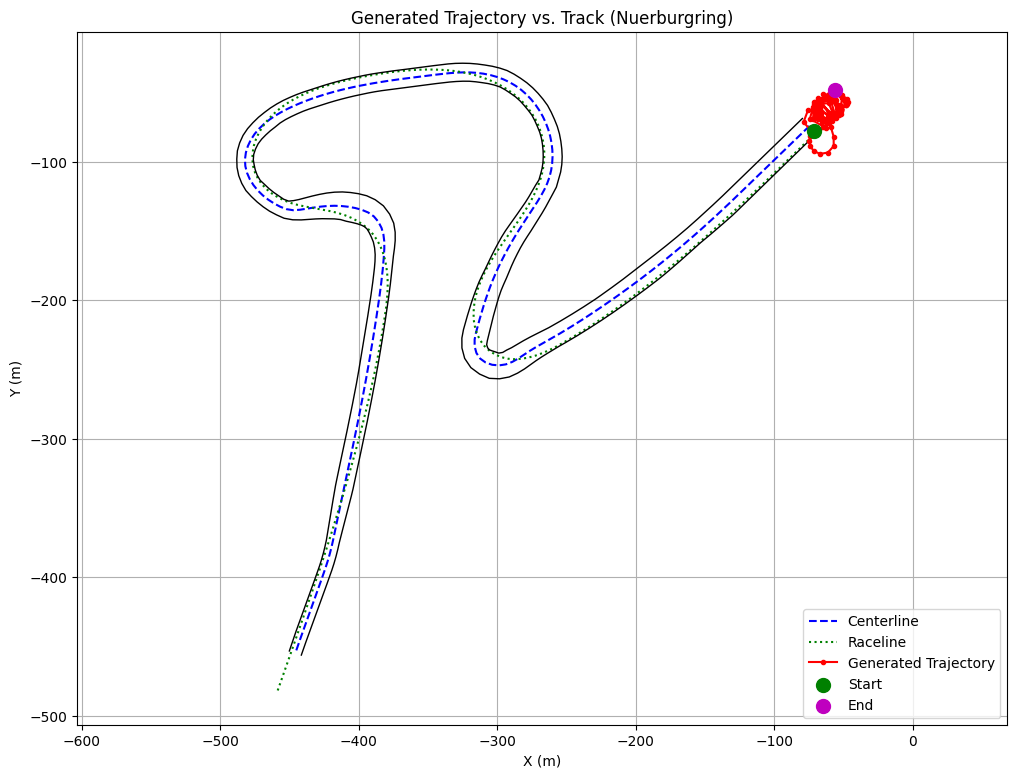

Fixed dt for this trajectory: 0.2000 seconds
Total trajectory time: 19.80 seconds


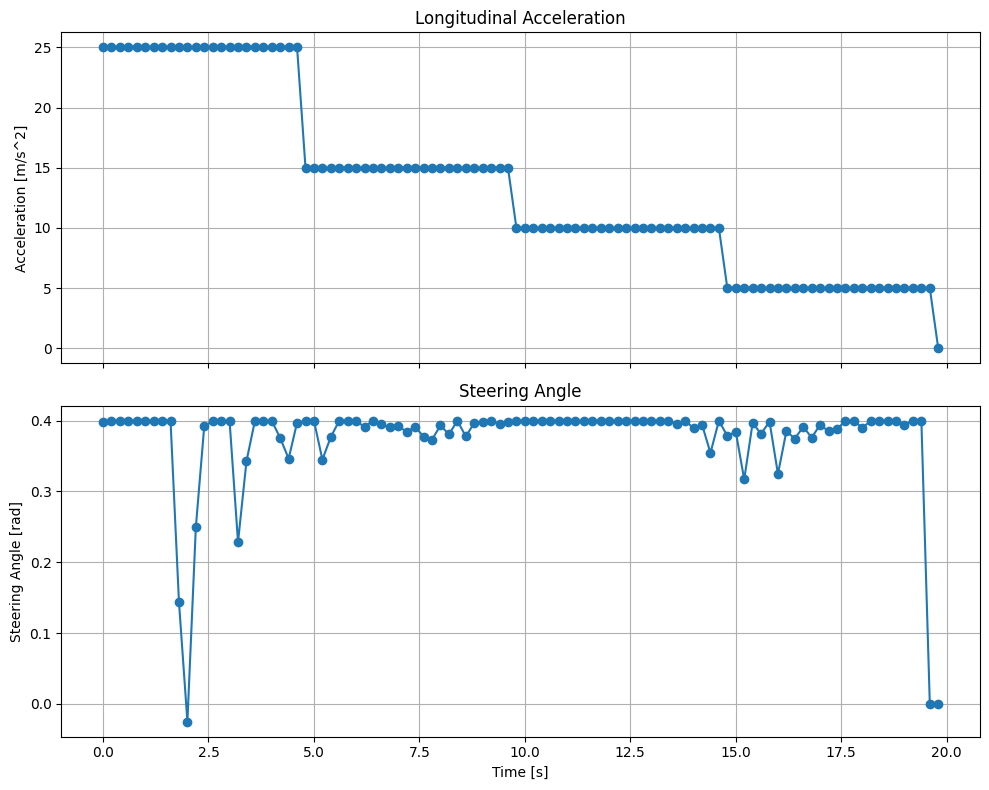

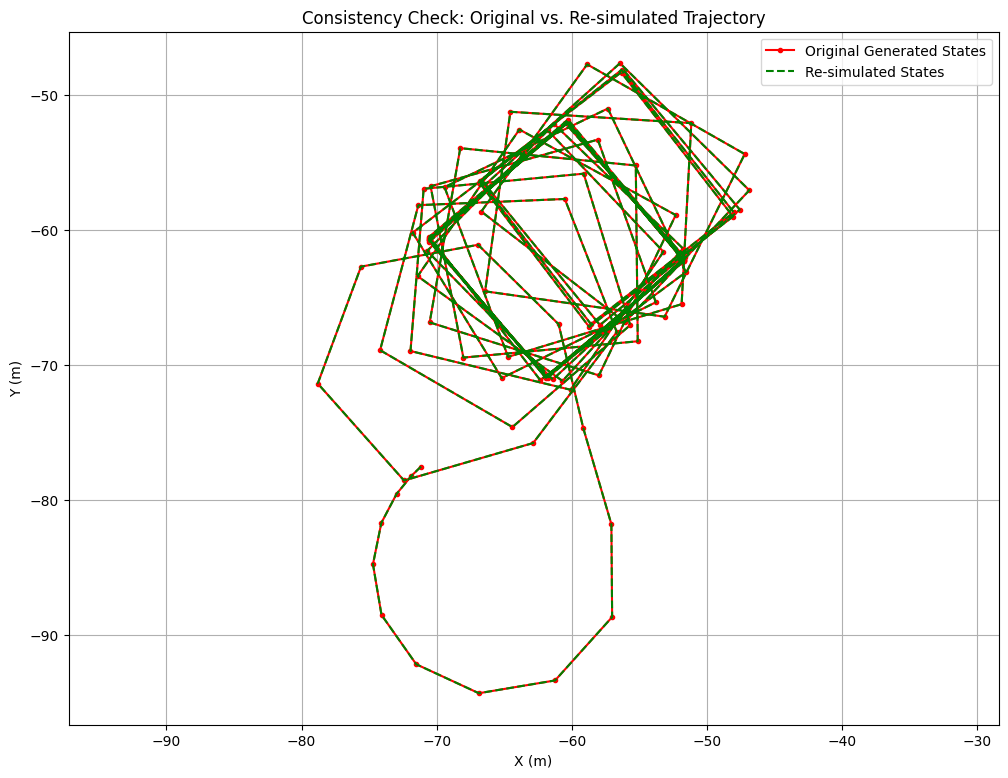

Maximum position error between original and re-simulated trajectory: 0.0000 m


In [ ]:
# ----------------------------
# MPC轨迹可视化和分析
# ----------------------------
if not mpc_trajectories:
    try:
        mpc_trajectories = np.load(save_filename, allow_pickle=True)
        print(f"从文件加载了 {len(mpc_trajectories)} 条MPC轨迹")
    except FileNotFoundError:
        print("没有找到轨迹数据文件，请先运行MPC数据收集部分")

if mpc_trajectories:
    print(f"\n=== MPC轨迹数据分析 ===")
    print(f"总轨迹数量: {len(mpc_trajectories)}")
    
    # 1. 所有轨迹概览
    plt.figure(figsize=(15, 10))
    
    # 绘制赛道
    plt.plot(track_segment['x_m'], track_segment['y_m'], 'b--', linewidth=2, label='中心线')
    if raceline_segment is not None:
        plt.plot(raceline_segment['x_m'], raceline_segment['y_m'], 'g:', linewidth=3, label='赛道线 (最优)')
    plt.plot(left_boundary_segment[:, 0], left_boundary_segment[:, 1], 'k-', linewidth=2, label='赛道边界')
    plt.plot(right_boundary_segment[:, 0], right_boundary_segment[:, 1], 'k-', linewidth=2)
    
    # 绘制所有MPC轨迹
    colors = ['red', 'orange', 'purple']
    for i, traj_data in enumerate(mpc_trajectories):
        states = traj_data['states']
        color = colors[i % len(colors)]
        
        plt.plot(states[:, 0], states[:, 1], '-', color=color, linewidth=2, 
                alpha=0.8, label=f'MPC轨迹 {i+1}')
        plt.scatter(states[0, 0], states[0, 1], c=color, s=150, marker='o', 
                   edgecolor='black', zorder=5)
        plt.scatter(states[-1, 0], states[-1, 1], c=color, s=150, marker='s', 
                   edgecolor='black', zorder=5)
    
    plt.title(f'MPC轨迹生成结果 - {track_name} 赛道段', fontsize=16)
    plt.xlabel('X坐标 (m)', fontsize=12)
    plt.ylabel('Y坐标 (m)', fontsize=12)
    plt.axis('equal')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 2. 选择一条轨迹进行详细分析
    selected_idx = 0
    selected_traj = mpc_trajectories[selected_idx]
    states = selected_traj['states']
    controls = selected_traj['controls']
    dt_used = selected_traj['dt']
    
    print(f"\n=== 详细分析轨迹 {selected_idx+1} ===")
    print(f"时间步长: {dt_used} 秒")
    print(f"总时间: {selected_traj['total_time']} 秒")
    print(f"轨迹点数: {len(states)}")
    print(f"MPC范围: {selected_traj['mpc_horizon']} 步")
    
    # 创建时间轴
    time_steps = np.arange(len(controls)) * dt_used
    time_steps_states = np.arange(len(states)) * dt_used
    
    # 2a. 控制输入可视化
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # 加速度
    ax1.plot(time_steps, controls[:, 0], 'b-o', markersize=3)
    ax1.set_ylabel('纵向加速度 [m/s²]')
    ax1.set_title('MPC控制输入 - 加速度')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=a_max, color='r', linestyle='--', alpha=0.7, label=f'上限: {a_max}')
    ax1.axhline(y=a_min, color='r', linestyle='--', alpha=0.7, label=f'下限: {a_min}')
    ax1.legend()
    
    # 转向角
    ax2.plot(time_steps, controls[:, 1], 'g-o', markersize=3)
    ax2.set_ylabel('转向角 [rad]')
    ax2.set_title('MPC控制输入 - 转向角')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=delta_max, color='r', linestyle='--', alpha=0.7, label=f'上限: {delta_max:.2f}')
    ax2.axhline(y=-delta_max, color='r', linestyle='--', alpha=0.7, label=f'下限: {-delta_max:.2f}')
    ax2.legend()
    
    # 速度
    ax3.plot(time_steps_states, states[:, 3], 'm-', linewidth=2)
    ax3.set_xlabel('时间 [s]')
    ax3.set_ylabel('速度 [m/s]')
    ax3.set_title('车辆状态 - 速度')
    ax3.grid(True, alpha=0.3)
    
    # 偏航角速度
    ax4.plot(time_steps_states, states[:, 4], 'c-', linewidth=2)
    ax4.set_xlabel('时间 [s]')
    ax4.set_ylabel('偏航角速度 [rad/s]')
    ax4.set_title('车辆状态 - 偏航角速度')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 3. 轨迹性能分析
    total_distance = np.sum([np.linalg.norm(states[i+1, :2] - states[i, :2]) 
                            for i in range(len(states)-1)])
    straight_line_distance = np.linalg.norm(states[-1, :2] - states[0, :2])
    efficiency = straight_line_distance / total_distance if total_distance > 0 else 0
    
    max_speed = np.max(states[:, 3])
    min_speed = np.min(states[:, 3])
    avg_speed = np.mean(states[:, 3])
    
    max_accel = np.max(controls[:, 0])
    min_accel = np.min(controls[:, 0])
    max_steering = np.max(np.abs(controls[:, 1]))
    
    print(f"\n=== 轨迹性能指标 ===")
    print(f"总行驶距离: {total_distance:.1f} m")
    print(f"直线距离: {straight_line_distance:.1f} m")
    print(f"路径效率: {efficiency:.3f}")
    print(f"最大速度: {max_speed:.1f} m/s")
    print(f"最小速度: {min_speed:.1f} m/s")
    print(f"平均速度: {avg_speed:.1f} m/s")
    print(f"最大加速度: {max_accel:.1f} m/s²")
    print(f"最大减速度: {min_accel:.1f} m/s²")
    print(f"最大转向角: {max_steering:.3f} rad ({np.degrees(max_steering):.1f}°)")
    
    # 4. 与赛道线的偏差分析
    if raceline_segment is not None:
        raceline_xy = raceline_segment[['x_m', 'y_m']].values
        deviations = []
        
        for pos in states[:, :2]:
            distances = np.linalg.norm(raceline_xy - pos, axis=1)
            min_deviation = np.min(distances)
            deviations.append(min_deviation)
        
        deviations = np.array(deviations)
        
        plt.figure(figsize=(12, 6))
        plt.plot(time_steps_states, deviations, 'r-', linewidth=2)
        plt.xlabel('时间 [s]')
        plt.ylabel('与赛道线的偏差 [m]')
        plt.title('车辆轨迹与最优赛道线的偏差')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"\n=== 赛道线跟随性能 ===")
        print(f"平均偏差: {np.mean(deviations):.2f} m")
        print(f"最大偏差: {np.max(deviations):.2f} m")
        print(f"最小偏差: {np.min(deviations):.2f} m")
        print(f"偏差标准差: {np.std(deviations):.2f} m")
    
    # 5. 数据保存确认
    print(f"\n=== 数据保存信息 ===")
    print(f"文件名: {save_filename}")
    print(f"每条轨迹包含:")
    print(f"  - 状态数据: {len(states)} x 5 (x, y, θ, v, r)")
    print(f"  - 控制数据: {len(controls)} x 2 (a, δ)")
    print(f"  - 时间步长: {dt_used} 秒")
    print(f"  - 总模拟时间: {selected_traj['total_time']} 秒")
